# R-Factor Ranking -> Move Validation -- Results

Does ranking F&O stocks by **R-factor** (time-of-day-normalised RVOL) at an
intraday checkpoint reliably select stocks that turn out to be **>=2% movers**
(from the 9:15 open) -- and by how much over a random F&O stock?

This notebook renders the seven outputs from the saved substrate
(`rfactor_picks.parquet`, `rfactor_universe_daily.parquet`).  Re-run the
backtest with one line (see the config cell) and re-run this notebook to refresh.

**Read before concluding** (Section 7 of the spec):
- The from-9:15 hit rate drifts up across the morning partly because later
  top-N lists already contain revealed movers -- do **not** rank entry times by
  output #1.
- To choose *when to enter*, read output #3 (capturable-after-checkpoint).
- The verdict is **lift** (top-N hit rate - base rate), not raw hit rate.


In [1]:
# ── Config + re-run instructions ────────────────────────────────────
# One-line re-run of the whole backtest:
#     python strategies/RFactor/run_backtest.py
# (edit strategies/RFactor/config.py to change checkpoints, top_n, threshold...)
import sys, json
from pathlib import Path
ROOT = Path.cwd()
while ROOT.name and not (ROOT / "strategies" / "RFactor").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from strategies.RFactor.config import (CONFIG, PICKS_PATH, UNIVERSE_DAILY_PATH,
                                        SUMMARY_PATH, RUN_META_PATH)
from strategies.RFactor import analytics

plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
CHK = CONFIG["checkpoints"]
print("CONFIG:")
print(json.dumps(CONFIG, indent=2, default=str))


CONFIG:
{
  "checkpoints": [
    "09:25",
    "09:45",
    "10:00",
    "10:15",
    "10:30",
    "10:45",
    "11:00",
    "11:15",
    "11:30"
  ],
  "top_n": 10,
  "top_subset": 5,
  "rvol_lookback": 20,
  "move_threshold": 0.02,
  "move_reference": "09:15_open",
  "capture_bar": 0.0075,
  "test_period_days": 250,
  "universe": "fo_manifest",
  "exclude_corp_action_window": true,
  "min_day_candles": 300,
  "session_close_after": "15:20",
  "session_open": "09:15",
  "session_end": "15:30"
}


In [2]:
# ── Load substrate ──────────────────────────────────────────────────
picks = pd.read_parquet(PICKS_PATH)
daily = pd.read_parquet(UNIVERSE_DAILY_PATH)
summary = pd.read_csv(SUMMARY_PATH)
meta = json.loads(Path(RUN_META_PATH).read_text())

print(f"Test window : {meta['test_start']} -> {meta['test_end']}  "
      f"({meta['n_test_days']} trading days)")
print(f"Universe    : {meta['universe_size']} F&O symbols")
print(f"Dropped days: {meta['dropped_degenerate_days']}")
print(f"Base rate   : {meta['pooled_base_rate']*100:.1f}%  (eligible universe, full-day >=2%)")
print(f"Picks rows  : {len(picks):,}   Universe-daily rows: {len(daily):,}")
summary.round(3)


Test window : 2025-06-18 -> 2026-06-19  (248 trading days)
Universe    : 211 F&O symbols
Dropped days: ['2025-10-21', '2026-06-22']
Base rate   : 39.4%  (eligible universe, full-day >=2%)
Picks rows  : 22,320   Universe-daily rows: 52,328


,checkpoint,n_picks,topn_hit,top5_hit,base_rate,lift_topn,lift_top5,median_fav_move,pct_capturable,mean_picks_hit,churn
0,09:25,2480,0.730,0.788,0.394,0.336,0.394,0.012,0.652,7.302,0.229
1,09:45,2480,0.759,0.823,0.394,0.365,0.429,0.010,0.617,7.593,0.125
2,10:00,2480,0.769,0.825,0.394,0.374,0.431,0.010,0.582,7.685,0.110
3,10:15,2480,0.781,0.829,0.394,0.387,0.435,0.009,0.579,7.815,0.092
4,10:30,2480,0.784,0.844,0.394,0.390,0.450,0.009,0.543,7.843,0.079
5,10:45,2480,0.791,0.842,0.394,0.396,0.448,0.009,0.540,7.907,0.077
6,11:00,2480,0.796,0.852,0.394,0.402,0.457,0.008,0.529,7.964,0.065
7,11:15,2480,0.800,0.853,0.394,0.405,0.459,0.008,0.521,7.996,0.065
8,11:30,2480,0.802,0.853,0.394,0.408,0.459,0.007,0.499,8.020,NaN


## 1 + 2. Hit-rate curve (headline) and base-rate control -> **Lift**

Top-N and top-5 hit rates against the eligible-universe base rate.  The gap
(**lift**) is the verdict: if it is consistently positive and large, R-rank
selects movers.

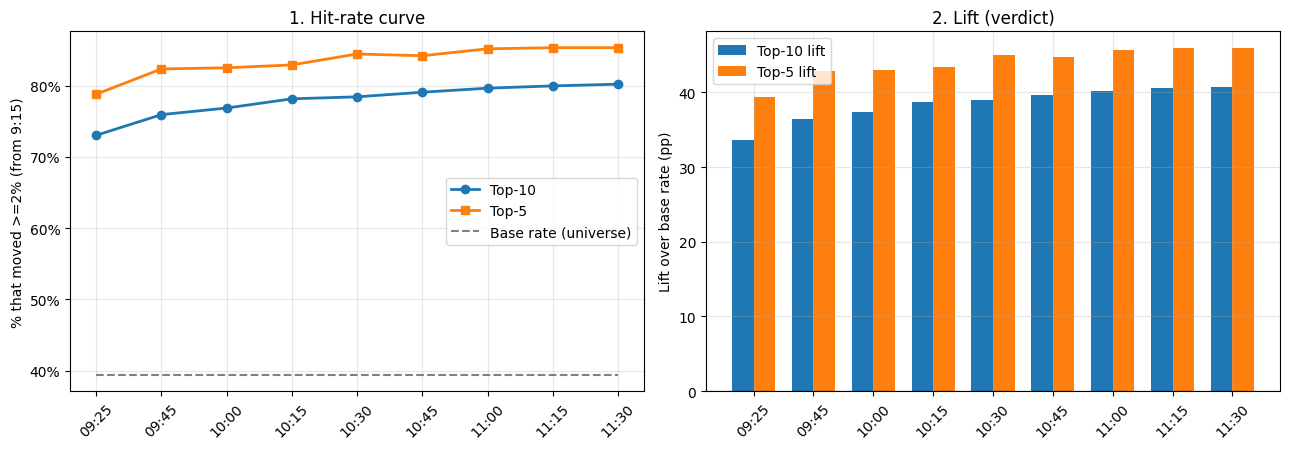

Mean top-10 lift: 38.5 pp | Mean top-5 lift: 44.0 pp


In [3]:
hr = analytics.hit_rate_curve(picks, daily)
x = np.arange(len(CHK))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
ax1.plot(x, hr["topn_hit"]*100, "o-", label=f"Top-{CONFIG['top_n']}", lw=2)
ax1.plot(x, hr["top5_hit"]*100, "s-", label=f"Top-{CONFIG['top_subset']}", lw=2)
ax1.plot(x, hr["base_rate"]*100, "--", color="grey", label="Base rate (universe)")
ax1.set_xticks(x); ax1.set_xticklabels(CHK, rotation=45)
ax1.set_ylabel("% that moved >=2% (from 9:15)"); ax1.set_title("1. Hit-rate curve")
ax1.legend(); ax1.yaxis.set_major_formatter(mtick.PercentFormatter())

ax2.bar(x-0.18, hr["lift_topn"]*100, width=0.36, label=f"Top-{CONFIG['top_n']} lift")
ax2.bar(x+0.18, hr["lift_top5"]*100, width=0.36, label=f"Top-{CONFIG['top_subset']} lift")
ax2.axhline(0, color="k", lw=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(CHK, rotation=45)
ax2.set_ylabel("Lift over base rate (pp)"); ax2.set_title("2. Lift (verdict)")
ax2.legend(); plt.tight_layout(); plt.show()

print(f"Mean top-{CONFIG['top_n']} lift: {hr['lift_topn'].mean()*100:.1f} pp | "
      f"Mean top-{CONFIG['top_subset']} lift: {hr['lift_top5'].mean()*100:.1f} pp")


## 3. Capturable-after-checkpoint -> **when to enter**

Favourable move (in the checkpoint direction) still available **after** the
checkpoint, measured from the checkpoint price.  This is the curve that picks
the entry time: it typically falls as the day's move exhausts.

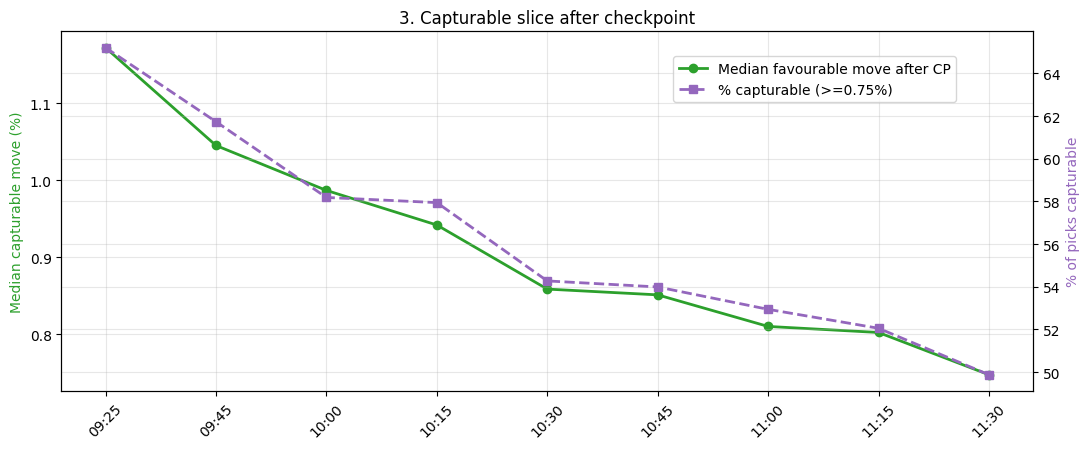

,checkpoint,median_fav_move,mean_fav_move,pct_capturable
0,09:25,1.17,0.015625,65.2
1,09:45,1.05,0.014033,61.7
2,10:00,0.99,0.013332,58.2
3,10:15,0.94,0.012851,57.9
4,10:30,0.86,0.012136,54.3
5,10:45,0.85,0.011831,54.0
6,11:00,0.81,0.011307,52.9
7,11:15,0.80,0.011163,52.1
8,11:30,0.75,0.010559,49.9


In [4]:
cc = analytics.capturable_curve(picks)
fig, ax1 = plt.subplots(figsize=(11, 4.6))
ax1.plot(x, cc["median_fav_move"]*100, "o-", color="tab:green", lw=2,
         label="Median favourable move after CP")
ax1.set_ylabel("Median capturable move (%)", color="tab:green")
ax1.set_xticks(x); ax1.set_xticklabels(CHK, rotation=45)
ax2 = ax1.twinx()
ax2.plot(x, cc["pct_capturable"]*100, "s--", color="tab:purple", lw=2,
         label=f"% capturable (>={CONFIG['capture_bar']*100:.2f}%)")
ax2.set_ylabel("% of picks capturable", color="tab:purple")
ax1.set_title("3. Capturable slice after checkpoint")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88)); plt.tight_layout(); plt.show()
cc.assign(median_fav_move=lambda d:(d.median_fav_move*100).round(2),
          pct_capturable=lambda d:(d.pct_capturable*100).round(1))


## 4. Churn / persistence

Fraction of a checkpoint's top-N still in the top-N at the next checkpoint.
High churn early means later checkpoints earn their keep (the leaderboard is
still re-shuffling); low churn means the early list mostly holds.

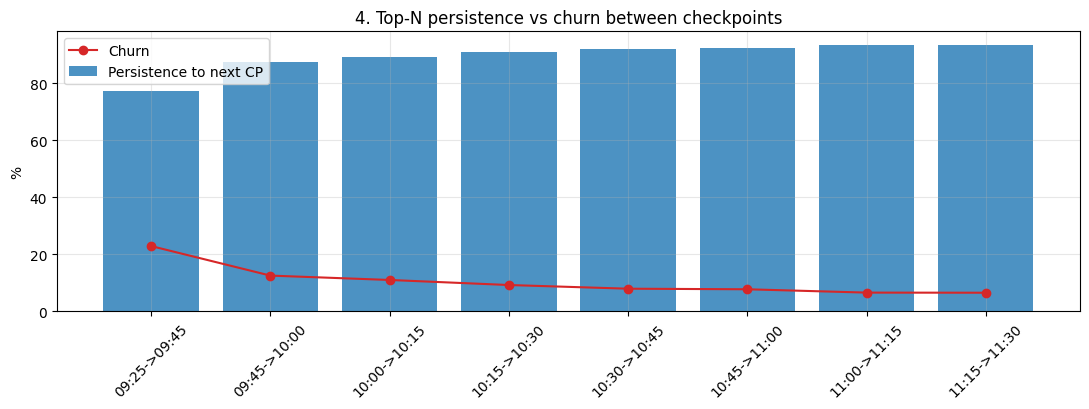

,checkpoint,next_checkpoint,persistence,churn
0,09:25,09:45,77.1,22.9
1,09:45,10:00,87.5,12.5
2,10:00,10:15,89.0,11.0
3,10:15,10:30,90.8,9.2
4,10:30,10:45,92.1,7.9
5,10:45,11:00,92.3,7.7
6,11:00,11:15,93.5,6.5
7,11:15,11:30,93.5,6.5


In [5]:
ch = analytics.churn_curve(picks, CHK)
xx = np.arange(len(ch))
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(xx, ch["persistence"]*100, color="tab:blue", alpha=0.8, label="Persistence to next CP")
ax.plot(xx, ch["churn"]*100, "o-", color="tab:red", label="Churn")
ax.set_xticks(xx); ax.set_xticklabels([f"{a}->{b}" for a,b in zip(ch.checkpoint, ch.next_checkpoint)], rotation=45)
ax.set_ylabel("%"); ax.set_title("4. Top-N persistence vs churn between checkpoints")
ax.legend(); plt.tight_layout(); plt.show()
ch.assign(persistence=lambda d:(d.persistence*100).round(1), churn=lambda d:(d.churn*100).round(1))


## 5. Per-day distribution -- how many of the 10 hit

On a typical day, how many of the top-N picks gave a >=2% move.

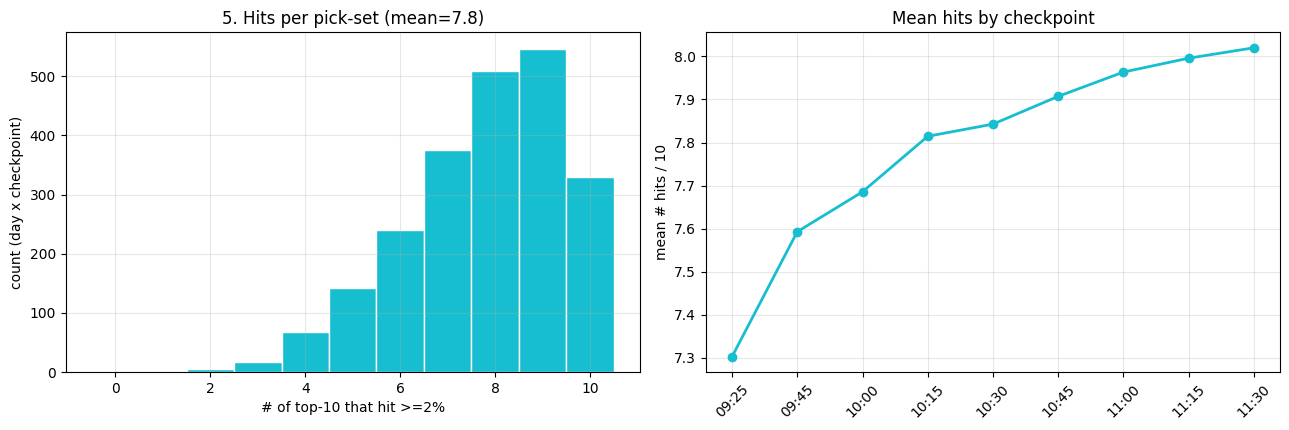

count    2232.00
mean        7.79
std         1.65
min         2.00
25%         7.00
50%         8.00
75%         9.00
max        10.00


In [6]:
ppd = analytics.picks_per_day_distribution(picks)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))
# histogram pooled across all (day, checkpoint)
bins = np.arange(0, CONFIG["top_n"]+2)-0.5
a1.hist(ppd["n_hits"], bins=bins, color="tab:cyan", edgecolor="white")
a1.set_xlabel(f"# of top-{CONFIG['top_n']} that hit >=2%"); a1.set_ylabel("count (day x checkpoint)")
a1.set_title(f"5. Hits per pick-set (mean={ppd['n_hits'].mean():.1f})")
# mean hits by checkpoint
mbc = ppd.groupby("checkpoint")["n_hits"].mean().reindex(CHK)
a2.plot(x, mbc.values, "o-", color="tab:cyan", lw=2)
a2.set_xticks(x); a2.set_xticklabels(CHK, rotation=45)
a2.set_ylabel(f"mean # hits / {CONFIG['top_n']}"); a2.set_title("Mean hits by checkpoint")
plt.tight_layout(); plt.show()
print(ppd["n_hits"].describe().round(2).to_string())


## 6. Direction split

Among the hitting picks, the up/down/both breakdown -- confirms the signal is
not secretly one-directional (R-factor carries no direction by construction).

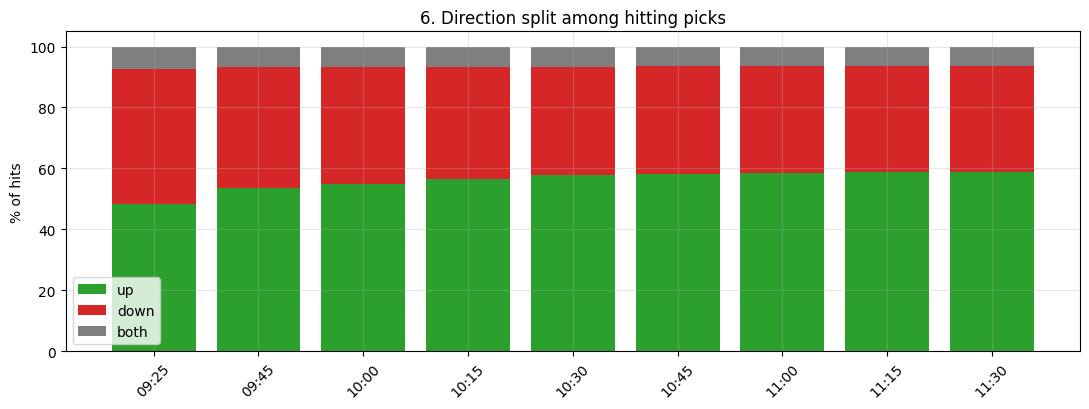

,checkpoint,n_hits,pct_up,pct_down,pct_both
0,09:25,1811,48.3,44.2,7.5
1,09:45,1883,53.7,39.5,6.9
2,10:00,1906,54.9,38.3,6.8
3,10:15,1938,56.4,36.8,6.8
4,10:30,1945,57.9,35.4,6.6
5,10:45,1961,58.3,35.3,6.4
6,11:00,1975,58.5,35.0,6.5
7,11:15,1983,58.7,34.8,6.5
8,11:30,1989,58.9,34.6,6.5


In [7]:
ds = analytics.direction_split(picks)
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(x, ds["pct_up"]*100, label="up", color="tab:green")
ax.bar(x, ds["pct_down"]*100, bottom=ds["pct_up"]*100, label="down", color="tab:red")
ax.bar(x, ds["pct_both"]*100, bottom=(ds["pct_up"]+ds["pct_down"])*100, label="both", color="tab:gray")
ax.set_xticks(x); ax.set_xticklabels(CHK, rotation=45)
ax.set_ylabel("% of hits"); ax.set_title("6. Direction split among hitting picks"); ax.legend()
plt.tight_layout(); plt.show()
ds.assign(pct_up=lambda d:(d.pct_up*100).round(1), pct_down=lambda d:(d.pct_down*100).round(1),
          pct_both=lambda d:(d.pct_both*100).round(1))


## 7. Magnitude distribution

How far the picks actually travelled (max abs move from 9:15).  Confirms the
moves are big enough to pay an option buyer (>=3%, >=5%), not just clear 2%.

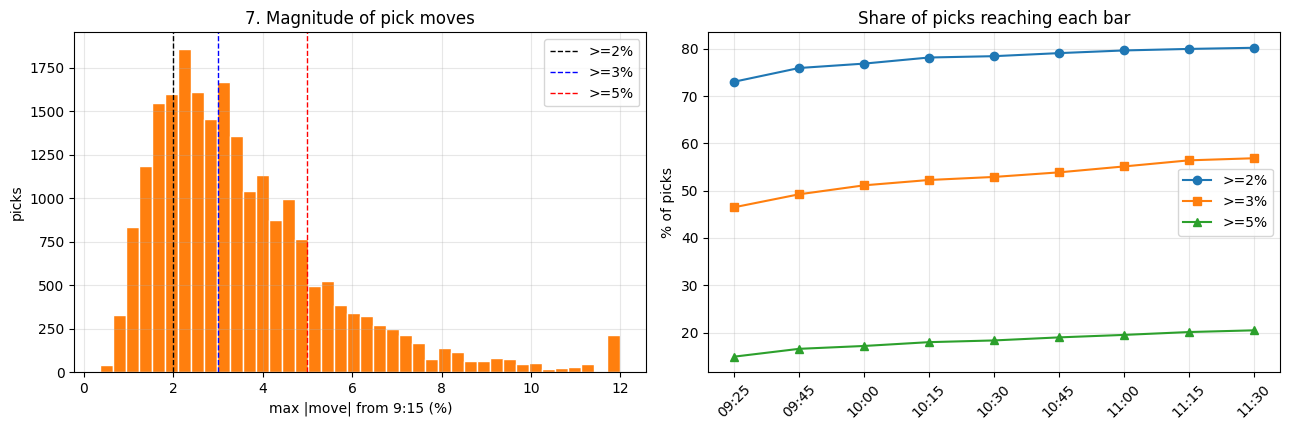

,checkpoint,pct_ge_2,pct_ge_3,pct_ge_5,median_abs_move
0,09:25,73.0,46.5,14.9,2.83
1,09:45,75.9,49.2,16.6,2.97
2,10:00,76.9,51.1,17.2,3.03
3,10:15,78.1,52.3,18.0,3.06
4,10:30,78.4,52.9,18.3,3.09
5,10:45,79.1,53.9,19.0,3.15
6,11:00,79.6,55.1,19.5,3.18
7,11:15,80.0,56.4,20.1,3.23
8,11:30,80.2,56.9,20.5,3.26


In [8]:
mg = analytics.magnitude_distribution(picks)
p = picks.copy(); p["abs_move"] = p[["max_up_pct","max_down_pct"]].max(axis=1)
fig, (b1, b2) = plt.subplots(1, 2, figsize=(13, 4.4))
b1.hist(np.clip(p["abs_move"]*100, 0, 12), bins=40, color="tab:orange", edgecolor="white")
for thr,c in [(2,"k"),(3,"b"),(5,"r")]:
    b1.axvline(thr, color=c, ls="--", lw=1, label=f">={thr}%")
b1.set_xlabel("max |move| from 9:15 (%)"); b1.set_ylabel("picks"); b1.set_title("7. Magnitude of pick moves"); b1.legend()
b2.plot(x, mg["pct_ge_2"]*100, "o-", label=">=2%")
b2.plot(x, mg["pct_ge_3"]*100, "s-", label=">=3%")
b2.plot(x, mg["pct_ge_5"]*100, "^-", label=">=5%")
b2.set_xticks(x); b2.set_xticklabels(CHK, rotation=45); b2.set_ylabel("% of picks"); b2.legend()
b2.set_title("Share of picks reaching each bar")
plt.tight_layout(); plt.show()
mg.assign(pct_ge_2=lambda d:(d.pct_ge_2*100).round(1), pct_ge_3=lambda d:(d.pct_ge_3*100).round(1),
          pct_ge_5=lambda d:(d.pct_ge_5*100).round(1), median_abs_move=lambda d:(d.median_abs_move*100).round(2))


## Summary -- does this work, and when?

The one-look verdict table: per-checkpoint top-N hit, base rate, lift,
capturable slice and churn.

In [9]:
disp = summary.copy()
pct = ["topn_hit","top5_hit","base_rate","lift_topn","lift_top5","median_fav_move","pct_capturable","churn"]
for c in pct:
    if c in disp: disp[c] = (disp[c]*100).round(1)
disp["mean_picks_hit"] = disp["mean_picks_hit"].round(1)
disp


,checkpoint,n_picks,topn_hit,top5_hit,base_rate,lift_topn,lift_top5,median_fav_move,pct_capturable,mean_picks_hit,churn
0,09:25,2480,73.0,78.8,39.4,33.6,39.4,1.2,65.2,7.3,22.9
1,09:45,2480,75.9,82.3,39.4,36.5,42.9,1.0,61.7,7.6,12.5
2,10:00,2480,76.9,82.5,39.4,37.4,43.1,1.0,58.2,7.7,11.0
3,10:15,2480,78.1,82.9,39.4,38.7,43.5,0.9,57.9,7.8,9.2
4,10:30,2480,78.4,84.4,39.4,39.0,45.0,0.9,54.3,7.8,7.9
5,10:45,2480,79.1,84.2,39.4,39.6,44.8,0.9,54.0,7.9,7.7
6,11:00,2480,79.6,85.2,39.4,40.2,45.7,0.8,52.9,8.0,6.5
7,11:15,2480,80.0,85.3,39.4,40.5,45.9,0.8,52.1,8.0,6.5
8,11:30,2480,80.2,85.3,39.4,40.8,45.9,0.7,49.9,8.0,NaN


In [10]:
best = analytics.capturable_curve(picks)
hrr = analytics.hit_rate_curve(picks, daily)
print("VERDICT")
print(f"  - R-rank lift over base rate: top-{CONFIG['top_n']} avg "
      f"{hrr['lift_topn'].mean()*100:.0f} pp, top-{CONFIG['top_subset']} avg "
      f"{hrr['lift_top5'].mean()*100:.0f} pp -> signal is {'STRONG' if hrr['lift_topn'].mean()>0.1 else 'WEAK'}.")
print(f"  - Top-{CONFIG['top_subset']} is sharper than top-{CONFIG['top_n']} at every checkpoint: "
      f"{(hrr['top5_hit']>hrr['topn_hit']).all()}")
early = best.iloc[0]; late = best.iloc[-1]
print(f"  - Capturable slice falls {early['median_fav_move']*100:.2f}% (at {best.iloc[0]['checkpoint']}) "
      f"-> {late['median_fav_move']*100:.2f}% (at {best.iloc[-1]['checkpoint']}): enter earlier.")


VERDICT
  - R-rank lift over base rate: top-10 avg 38 pp, top-5 avg 44 pp -> signal is STRONG.
  - Top-5 is sharper than top-10 at every checkpoint: True
  - Capturable slice falls 1.17% (at 09:25) -> 0.75% (at 11:30): enter earlier.
